In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [16]:
cause_fracs = pd.read_csv("/Users/alexepstein/Dropbox @RU Dropbox/Alexander Epstein/Rockefeller University/Cao Lab/Thesis Defense/longevity-simulator/data/cause_fractions_male.csv", index_col=0)
cause_fracs.sum(axis=1)

age_years
0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
101    1.0
102    1.0
103    1.0
104    1.0
105    1.0
Length: 106, dtype: float64

In [ ]:
def log_gompertz_makeham(x, a, b, c):
    return np.log(a * np.exp(b * x) + c)

def log_gompertz(x, a, b):
    return np.log(a) + b * x


class Condition:
    def __init__(self, aging_rate=1, slow_at=25, causes_to_remove=[], name=None):
        
        causes_to_remove = list(causes_to_remove)
        
        if name is None:
            if aging_rate == 1:
                name = 'Age at normal speed'
            else:
                name = 'Age at %s\% of normal starting at %s' % (aging_rate * 100, slow_at)
                
            if causes_to_remove:
                name += '. Remove causes: %s' % ', '.join(causes)
                
        self.aging_rate = aging_rate
        self.adjust_at = adjust_at
        self.causes_to_include = causes_to_include
        self.name = name
        
        
def adjustMortalityRates(mortality_rates, cause_fractions, aging_rate=1, slow_at=25, causes_to_remove=[]):
    causes_to_remove = list(causes_to_remove)
    # Making any adjustments
    included_causes_frac = true_cause_fractions.drop(causes_to_remove, axis=1).sum(axis=1)
    mortality_rates = mortality_rates.multiply(included_causes_frac, axis=0)

    adjustments = np.ones(len(mortality_rates))
    adjustments[int(adjust_at):] *= self.aging_rate
    mortality_rates = mortality_rates.multiply(adjustments, axis=0)
    
    return mortality_rates


def padMortalityRates(mortality_rates, pad_to=200):
    pad_index = np.arange(len(mortality_rates)+1, pad_to)
    pad = pd.Series(mortality_rates[-1], pad_index)
    return pd.concat(mortality_rates, pad)
        

def getSurvivalCurve(mortality_rates):
    return np.cumprod(1-mortality_rates)
        

def fitGompertz(mortality_rates, use_makeham=False, fit_region=[25, 100]):
    x_full = np.arange(len(mortality_rates))
    x_trimmed = x_full[fit_region[0]:fit_region[1]]
    y_trimmed = mortality_rates[fit_region[0]:fit_region[1]]
    y_log = np.log(y_trimmed)
    if use_makeham:
        params, cov = curve_fit(log_gompertz_makeham, x, y_log, p0=(1, 0.1, 0.01), bounds=([1e-12, 1e-12, 0], [1, 1, 1]))
        y_pred = np.exp(log_gompertz_makeham(x_full, *params))
    else:
        params, cov = curve_fit(log_gompertz, x, y_log, p0=(1, 0.1), bounds=([1e-12, 1e-12], [1, 1]))
        y_pred = np.exp(log_gompertz(x_full, *params))
    
    return x_full, y_pred, params, cov
    


def plotMortalityCurves(mortality_rates, cause_fractions, conditions=[Condition()], pad_to=200, gompertz_fit_region=[25, 100], use_makeham=False, gompertz_remove_accidents=True):
    
    for condition in conditions:
        name = condition.name
        aging_rate = condition.aging_rate
        causes_to_remove = condition.causes_to_remove
        adjust_at = condition.adjust_at
        
        
        # Adjust and pad mortality
        mortality_adj = adjustMortalityRates(mortality_rates, cause_fractions, aging_rate, slow_at, causes_to_remove)
        mortality_adj = padMoratalityRates(mortality_adj, pad_to)
        
        # Get survival curve
        survival_curve = getSurvivalCurve(mortality_adj)
        
        # Fit Gompertz
        if gompertz_remove_accidents:
            gompertz_mortality = adjustMortalityRates(mortality_rates, cause_fractions, aging_rate, slow_at, causes_to_remove + ['External'])
        else:
            gompertz_mortality = mortality_adj    
        
        x_full, y_pred, params, cov = fitGompertz(gompertz_mortality, use_makeham, gompertz_fit_region)
        
        # Add to Gompertz 
        
        
        
        
        
        
        
        
        
    
    # Parse conditions
    
    
    

IndentationError: expected an indented block after 'if' statement on line 27 (2187551796.py, line 32)

In [10]:
mortality_rates = pd.read_csv("../data/mortality_rates_total.csv", header=0, index_col=0)


In [11]:
mortality_rates

,mx
Age,
0,0.00588
1,0.00040
2,0.00026
3,0.00019
4,0.00016
...,...
105,0.55368
106,0.58566
107,0.61701


In [ ]:
life_table = pd.read_csv("data/mortality_rates_total.csv", skiprows=2, delim_whitespace=True)
life_table = life_table[life_table['Age'] != '110+']
life_table['Age'] = life_table['Age'].astype(int)
life_table = life_table[life_table['Year']=='2010-2019'].set_index('Age')
true_mortality_rate = life_table['mx'].astype('float')

def stop_aging(true_mortality_rate, final_age, pad_to_age=0):
    out = true_mortality_rate.copy()
    out.index = out.index.astype(int)
    out = out.sort_index()
    
    current_max_age = out.index[-1]
    
    if final_age < current_max_age:
        final_mortality_rate = out[final_age]
        out[final_age:] = final_mortality_rate
    else:
        final_mortality_rate = out[current_max_age]
    
    
    if pad_to_age > current_max_age:
        final_death_rate = out.loc[current_max_age]
        out_pad_index = np.arange(current_max_age+1, pad_to_age)
        out_pad = pd.Series(final_death_rate, index=out_pad_index)
        out = pd.concat([out, out_pad])
    
    
    return out

def slowAging(true_mortality_rate, slow_factor, start_age=0, pad_to_age=0):
    """
    Returns a Series with the same index as true_mortality_rate, but with "slowed" aging
    starting from start_age.
    
    Parameters:
    -----------
    true_mortality_rate : pd.Series
        Mortality rates indexed by age
    slow_factor : float
        Factor to slow aging by (e.g., 0.5 means age half as fast)
    start_age : int
        Age at which to begin slowing aging. Before this age, uses normal rates.
    pad_to_age : int
        Optional padding to extend the series to this age
        
    Example:
    --------
    If start_age=30 and slow_factor=0.5:
    - Ages 0-29: normal mortality rates
    - Age 30: mortality rate of age 30
    - Age 40: mortality rate of age 30 + (40-30)*0.5 = age 35
    - Age 60: mortality rate of age 30 + (60-30)*0.5 = age 45
    """
    out = true_mortality_rate.copy()
    out.index = out.index.astype(int)
    out = out.sort_index()

    min_age = out.index.min()
    max_age = out.index.max()

    # Map each age to its effective biological age
    new_index = out.index
    mapped_ages = np.zeros(len(new_index), dtype=int)
    
    for i, age in enumerate(new_index):
        if age < start_age:
            # Before start_age: use normal age
            mapped_ages[i] = age
        else:
            # After start_age: slow down aging
            # mapped_age = start_age + (age - start_age) * slow_factor
            mapped_ages[i] = int(start_age + (age - start_age) * slow_factor)
    
    # Clip to valid range
    mapped_ages = np.clip(mapped_ages, min_age, max_age)
    slowed_rates = pd.Series([out.loc[age] for age in mapped_ages], index=new_index)

    # Pad after
    if pad_to_age > max_age:
        final_death_rate = slowed_rates.iloc[-1]
        pad_index = np.arange(max_age + 1, pad_to_age + 1)
        pad_vals = pd.Series(final_death_rate, index=pad_index)
        slowed_rates = pd.concat([slowed_rates, pad_vals])

    return slowed_rates




/var/folders/nm/2x8tcvbj40qb_g087p5lw03c0000gn/T/ipykernel_80856/96952462.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  life_table = pd.read_csv("data/life_table_total.txt", skiprows=2, delim_whitespace=True)


FileNotFoundError: [Errno 2] No such file or directory: 'data/life_table_total.txt'

In [6]:
# Function to categorize ICD-10 codes into major cause categories
def categorize_cause(icd_list):
    """
    Categorize ICD-10 codes. Uses the first code in the list (underlying cause).
    record_axis_conditions contains a list like ['C349', 'F179']
    """
    # Check for None first
    if icd_list is None:
        return 'Unknown'
    
    # Check if it's a scalar NaN (not a list)
    try:
        if pd.isna(icd_list):
            return 'Unknown'
    except (TypeError, ValueError):
        pass  # Not a scalar, continue
    
    # Check if empty list
    if not isinstance(icd_list, list) or len(icd_list) == 0:
        return 'Unknown'
    
    # Use the first code (underlying cause of death)
    code = icd_list[0]
    
    if not code or code == 'None' or pd.isna(code):
        return 'Unknown'
    
    # Get the first letter of the ICD-10 code
    first_letter = str(code)[0].upper()
    
    # Categorize by ICD-10 chapter
    if first_letter == 'C' or (first_letter == 'D' and len(code) > 1 and code[1] in '01234'):
        return 'Cancer'
    elif first_letter == 'I':
        return 'Cardiovascular'
    elif first_letter == 'J':
        return 'Respiratory'
    elif first_letter == 'E':
        return 'Endocrine'
    elif first_letter == 'U' and str(code).startswith('U07'):
        return 'COVID-19'
    elif first_letter == 'K':
        return 'Digestive'
    elif first_letter == 'N':
        return 'Genitourinary'
    elif first_letter == 'G':
        return 'Neurological'
    elif first_letter == 'F':
        return 'Mental'
    elif first_letter in ['A', 'B']:
        return 'Infectious'
    elif first_letter in ['V', 'W', 'X', 'Y']:
        return 'External'
    else:
        return 'Other'
    
# Function to adjust life table by removing a cause of death
def remove_cause_from_lifetable(life_table_series, cause_fractions_df, cause_code, 
                                  use_wide_format=True):
    """
    Adjust a life table by removing deaths from a specific cause.
    
    Parameters:
    -----------
    life_table_series : pd.Series
        Mortality rates (mx) indexed by age
    cause_fractions_df : pd.DataFrame
        Either wide format (index=age, columns=causes) or 
        long format (columns=['age_years', 'cause_category', 'fraction'])
    cause_code : str
        The cause category to remove (e.g., 'Cancer', 'Cardiovascular', 'Respiratory', 'Endocrine')
    use_wide_format : bool
        True if cause_fractions_df is in wide format, False if long format
        
    Returns:
    --------
    pd.Series
        Adjusted mortality rates with the specified cause removed
        
    Example:
    --------
    If death rate at age 70 is 0.02 (2% die per year) and 'Cancer' 
    accounts for 25% of deaths at that age, then:
    - Deaths from cancer: 0.02 * 0.25 = 0.005
    - Adjusted death rate: 0.02 - 0.005 = 0.015 (removing cancer)
    - Or equivalently: 0.02 * (1 - 0.25) = 0.015
    """
    adjusted_rates = life_table_series.copy()
    
    if use_wide_format:
        # Wide format: index=age, columns=causes
        if cause_code not in cause_fractions_df.columns:
            raise ValueError(f"Cause code '{cause_code}' not found in dataframe columns")
        
        # Get fraction of deaths due to this cause at each age
        cause_fractions = cause_fractions_df[cause_code]
        
    else:
        # Long format: filter for the specific cause
        cause_data = cause_fractions_df[cause_fractions_df['cause_category'] == cause_code]
        cause_fractions = cause_data.set_index('age_years')['fraction']
    
    # Align indices between life table and cause fractions
    common_ages = adjusted_rates.index.intersection(cause_fractions.index)
    
    # Get the oldest age in the cause fractions data
    max_cause_age = cause_fractions.index.max() if len(cause_fractions) > 0 else 0
    
    # For each age in the life table
    for age in adjusted_rates.index:
        if age in common_ages:
            # Age exists in both - use actual fraction
            fraction_from_cause = cause_fractions.loc[age]
        elif age > max_cause_age and max_cause_age > 0:
            # Age beyond cause data - use fraction from oldest available age
            fraction_from_cause = cause_fractions.loc[max_cause_age]
        else:
            # Age below minimum in cause data - no adjustment
            fraction_from_cause = 0
        
        # New rate = Old rate * (1 - fraction_due_to_cause)
        adjusted_rates.loc[age] = adjusted_rates.loc[age] * (1 - fraction_from_cause)
    
    return adjusted_rates



In [7]:
df = pd.read_parquet('data/MMCD_2022.parquet', engine='fastparquet')
df['cause_category'] = df['record_axis_conditions'].apply(categorize_cause)
age_years_float = df['age_lower_bound'] / 1000 / 60 / 60 / 24 / 365.25
df['age_years'] = np.floor(age_years_float).astype('Int64')

# Remove rows with missing ages
missing_ages = df['age_years'].isna().sum()
df = df.dropna(subset=['age_years'])

# Remove rows with unknown age
df = df[df['age_years'] != 998]

# Note: We calculate only the wide format since that's what remove_cause_from_lifetable() uses
# Ages 105+ are grouped together to avoid sparse data issues at very old ages


# Calculate fractions (group ages 105+ together for stability)
print("Calculating cause fractions...")
print("  Note: Grouping ages 105+ together to avoid sparse data issues")

# Group old ages together
df_grouped = df.copy()
df_grouped = df_grouped[df_grouped['cause_category'] != 'COVID-19']
df_grouped.loc[df_grouped['age_years'] >= 105, 'age_years'] = 105

# Calculate counts (fast vectorized operations)
cause_by_age = df_grouped.groupby(['age_years', 'cause_category']).size()
total_by_age = df_grouped.groupby('age_years').size()

# Calculate fractions and pivot to wide format
cause_fractions_wide = cause_by_age.unstack(fill_value=0).div(total_by_age, axis=0)

# Sort columns by overall importance
column_order = cause_fractions_wide.mean().sort_values(ascending=False).index
cause_fractions_wide = cause_fractions_wide[column_order]

print(f"\nCause fractions table:")
print(f"  Shape: {cause_fractions_wide.shape}")
print(f"  Ages: {cause_fractions_wide.index.min()} to {cause_fractions_wide.index.max()} (where 105 = 105+)")
print(f"  Causes: {list(cause_fractions_wide.columns)}")
print(f"\nSample counts at different ages:")
for age in [50, 70, 90, 105]:
    if age <= 104:
        count = len(df[df['age_years'] == age])
    else:
        count = len(df[df['age_years'] >= 105])
    print(f"  Age {age}{'+'if age==105 else ''}: {count:,} deaths")


Calculating cause fractions...
  Note: Grouping ages 105+ together to avoid sparse data issues

Cause fractions table:
  Shape: (106, 11)
  Ages: 0 to 105 (where 105 = 105+)
  Causes: ['External', 'Cardiovascular', 'Cancer', 'Neurological', 'Respiratory', 'Other', 'Endocrine', 'Digestive', 'Mental', 'Infectious', 'Genitourinary']

Sample counts at different ages:
  Age 50: 21,152 deaths
  Age 70: 68,829 deaths
  Age 90: 72,708 deaths
  Age 105+: 1,425 deaths


In [62]:
test = remove_cause_from_lifetable(true_mortality_rate, cause_fractions_wide, 'External')
test = remove_cause_from_lifetable(test, cause_fractions_wide, 'Mental')

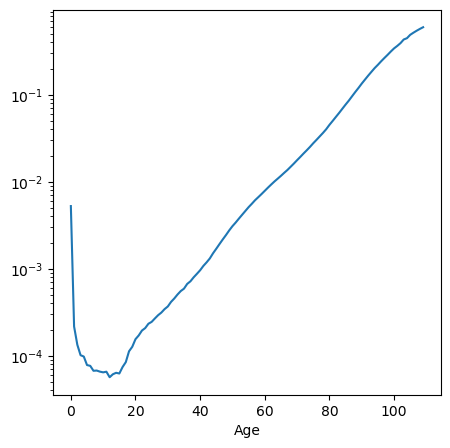

In [63]:
fig, ax = plt.subplots(figsize=(5, 5))
test.plot(ax=ax)
ax.set_yscale('log')

/var/folders/nm/2x8tcvbj40qb_g087p5lw03c0000gn/T/ipykernel_96294/1016873552.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  life_table = pd.read_csv("data/life_table_total.txt", skiprows=2, delim_whitespace=True)


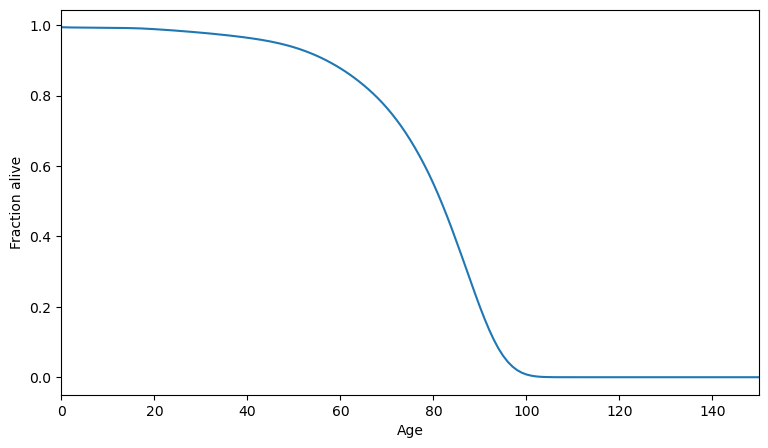

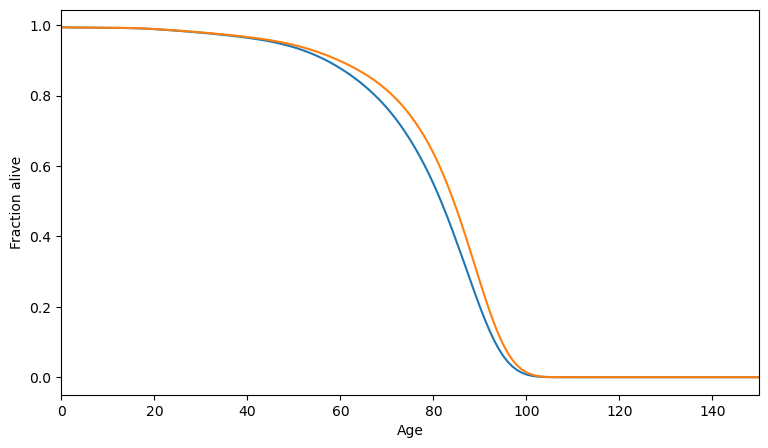

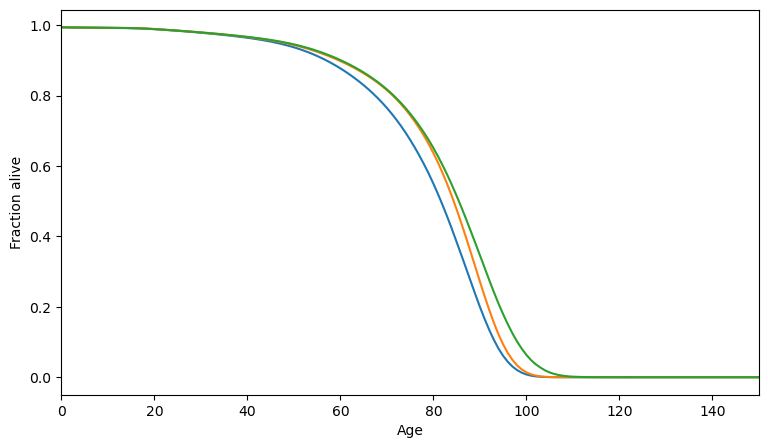

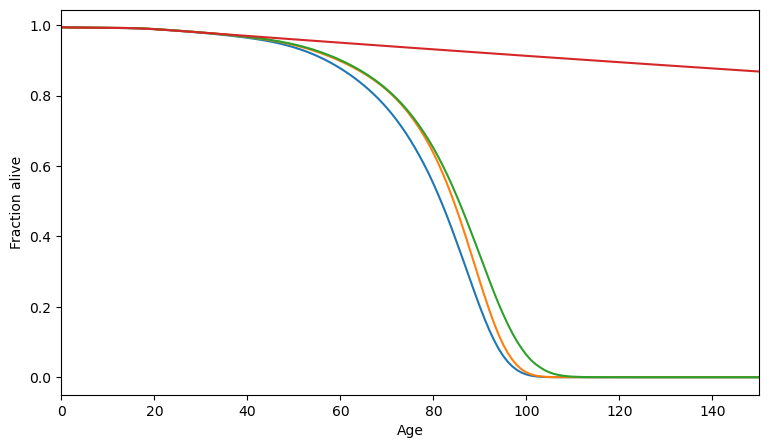

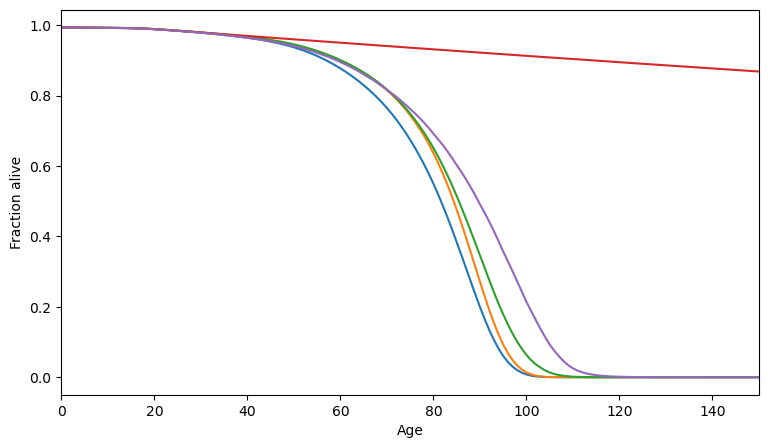

In [ ]:
life_table = pd.read_csv("data/life_table_total.txt", skiprows=2, delim_whitespace=True)
life_table = life_table[life_table['Age'] != '110+']
life_table['Age'] = life_table['Age'].astype(int)
life_table = life_table[life_table['Year']=='2010-2019'].set_index('Age')
true_mortality_rate = life_table['mx'].astype('float')

def stop_aging(true_mortality_rate, final_age, pad_to_age=0):
    out = true_mortality_rate.copy()
    out.index = out.index.astype(int)
    out = out.sort_index()
    
    current_max_age = out.index[-1]
    
    if final_age < current_max_age:
        final_mortality_rate = out[final_age]
        out[final_age:] = final_mortality_rate
    else:
        final_mortality_rate = out[current_max_age]
    
    
    if pad_to_age > current_max_age:
        final_death_rate = out.loc[current_max_age]
        out_pad_index = np.arange(current_max_age+1, pad_to_age)
        out_pad = pd.Series(final_death_rate, index=out_pad_index)
        out = pd.concat([out, out_pad])
    
    
    return out

stop_aging_vals = [25,55,70]
df = pd.DataFrame()
pad_to_age=1000

df['Current situation'] = stop_aging(true_mortality_rate, 110, pad_to_age)
mortality_no_cancer = remove_cause_from_lifetable(true_mortality_rate, cause_fractions_wide, 'Cancer')
df['Cure cancer'] = stop_aging(mortality_no_cancer, 110, pad_to_age)
mortality_no_cvd = remove_cause_from_lifetable(true_mortality_rate, cause_fractions_wide, 'Cardiovascular')
df['Solve cardiovascular disease'] = stop_aging(mortality_no_cvd, 110, pad_to_age)


df['Stop aging at 25'] = stop_aging(true_mortality_rate, 25, pad_to_age)
#df['Stop aging at 65'] = stop_aging(true_mortality_rate, 65, pad_to_age)
df['Slow aging 20% starting at 40'] = slowAging(true_mortality_rate, 0.8, 40, pad_to_age)
#df['Slow aging by 20%'] = slowAging(true_mortality_rate, slow_factor=0.8, pad_to_age=200)



survival_curves = pd.DataFrame({col: np.cumprod(1-df[col]) for col in df.columns})

columns = survival_curves.columns
median_lifespans = {}
for column in columns:
    median_lifespans[column] = survival_curves[survival_curves[column] < 0.5].index.min()

col_labels = {col:"%s: median lifespan = %d yr" % (col, median_lifespans[col]) for col in survival_curves.columns}
survival_curves = survival_curves.rename(columns=col_labels)



for i in range(1,survival_curves.shape[1]+1):
    df_sub = survival_curves.iloc[:,:i]

    
    fig, ax = plt.subplots(figsize=(9, 5))
    #colors = ['black', 'red', 'blue', 'green', 'orange', 'purple']
    df_sub.plot(ax=ax)
    ax.set_xlabel('Age')
    ax.set_ylabel('Fraction alive')
    ax.set_xlim([0, 150])
    #ax.legend(loc='upper left', bbox_to_anchor=(0, 0.5))
    ax.get_legend().remove()
    fig.savefig("results/survival_curve_{}.png".format(i))




In [255]:
columns = survival_curves.columns
median_lifespans = {}
for column in columns:
    median_lifespans[column] = survival_curves[survival_curves[column] < 0.5].index.min()

pd.Series(median_lifespans)

Current situation: median lifespan = 82 yr                 82
Cure cancer: median lifespan = 85 yr                       85
Solve cardiovascular disease: median lifespan = 86 yr      86
Stop aging at 25: median lifespan = 702 yr                702
Slow aging 20% starting at 40: median lifespan = 90 yr     90
dtype: int64

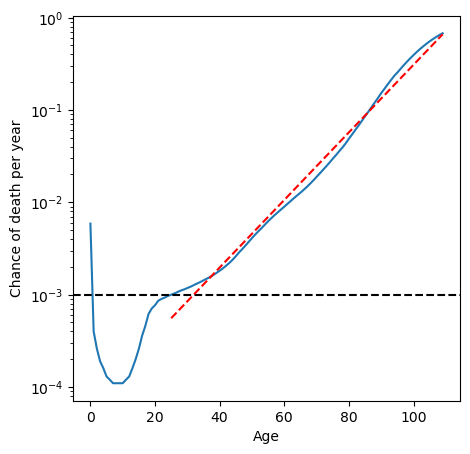

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
true_mortality_rate.plot(ax=ax)
ax.axhline(true_mortality_rate.loc[25], color='black', linestyle='--')

from scipy.stats import linregress

# Fit a line to the log of true_mortality_rate
xdata = true_mortality_rate[25:].index.values.astype(float)
ydata = np.log(true_mortality_rate[25:].values)

slope, intercept, r_value, p_value, std_err = linregress(xdata, ydata)



ax.set_yscale('log')

ax.set_xlabel('Age')
ax.set_ylabel('Chance of death per year')
fig.savefig("results/true_mortality_rate.png")

# Plot the exponential fit using the line
ax.plot(
    xdata,
    np.exp(intercept + slope * xdata),
    'r--',
    label='Exp fit: {:.2e}e^({:.3f}t)'.format(np.exp(intercept), slope)
)

fig.savefig("results/true_mortality_rate_with_fit.png")





In [ ]:
a = np.exp(intercept)

/var/folders/nm/2x8tcvbj40qb_g087p5lw03c0000gn/T/ipykernel_96294/3624723222.py:1: RuntimeWarning: invalid value encountered in log
  a = np.log(intercept)


In [17]:
true_mortality_rate

Age
0      0.00588
1      0.00040
2      0.00026
3      0.00019
4      0.00016
        ...   
105    0.55368
106    0.58566
107    0.61701
108    0.64748
109    0.67686
Name: mx, Length: 110, dtype: float64

In [29]:
params

array([ 0.00013878,  0.07877946, -0.00514083])

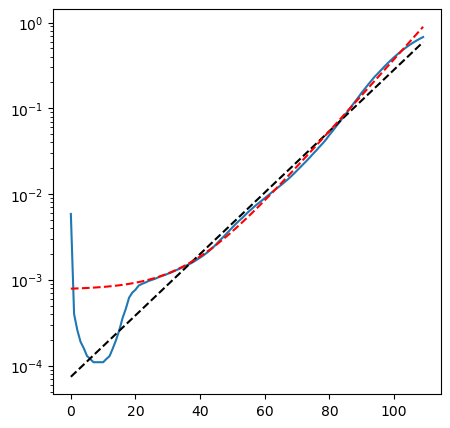

In [57]:
from scipy.optimize import curve_fit

def gompertz_makeham(x, a, b, c):
    return a * np.exp(b * x) + c

def log_gompertz_makeham(x, a, b, c):
    return np.log(a * np.exp(b * x) + c)

x_full = true_mortality_rate.index.values
y_true_full = true_mortality_rate.values
x = x_full[25:100]
y_true = y_true_full[25:100]
    
params, cov = curve_fit(gompertz_makeham, x, y_true, p0=(1, 0.1, 0))
y_pred_full = gompertz_makeham(x_full, *params)

y_true_log = np.log(y_true)
params_log, cov_log = curve_fit(log_gompertz_makeham, x, y_true_log, p0=(1, 0.1, 0.01), bounds=([1e-12, 1e-12, 0], [1, 1, 1]))
y_pred_full_log = np.exp(log_gompertz_makeham(x_full, *params_log))

# Linear fit to the log data
slope, intercept, r_value, p_value, std_err = linregress(x, y_true_log)
y_gompertz = np.exp(intercept + slope * x_full)


fig, ax = plt.subplots(figsize=(5, 5))
ax.set_yscale('log')
ax.plot(x_full, y_true_full, label='True mortality rate')
fig.savefig("results/true_mortality_rate.png")
ax.plot(x_full, y_gompertz, label='Gompertz fit', linestyle='--', color='black')
fig.savefig("results/gompertz_fit_mortality_rate.png")
ax.plot(x_full, y_pred_full_log, label='Gompertz-Makeham fit', linestyle='--', color='red')
fig.savefig("results/gompertz_makeham_fit_mortality_rate.png")


In [ ]:
a, b = params
x = np

array([0.00011255, 0.08068013])

In [232]:
life_expectancies = pd.read_csv("data/NCHS_life_expectancies.csv", index_col=0)

In [236]:
plot_df = life_expectancies[(life_expectancies['Race'] == 'All Races') & (life_expectancies['Sex'] == 'Both Sexes')]

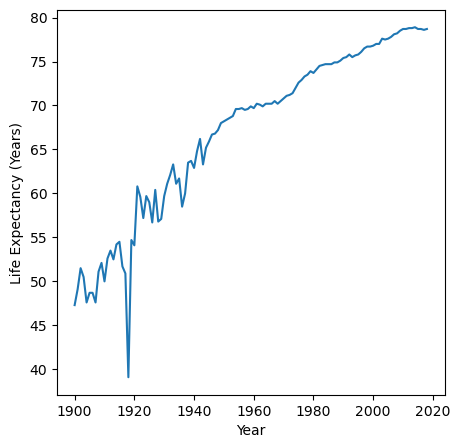

In [238]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_df['Average Life Expectancy (Years)'].plot(ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (Years)')
fig.savefig("results/life_expectancy.png")




Slope: 0.0843, Intercept: -9.6003, R^2: 0.9898


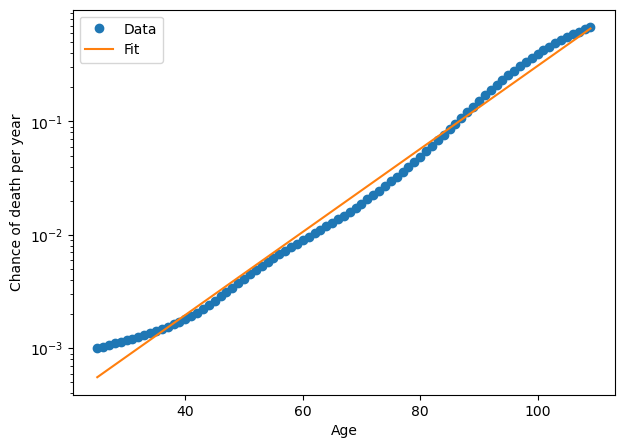

In [225]:
# Gompertz fit
from scipy.stats import linregress
import numpy as np

# Prepare data
x = true_mortality_rate[25:].index.values.astype(float)
y = np.log(true_mortality_rate[25:].values)

# Fit a line: log(mortality) = a * age + b
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R^2: {r_value ** 2:.4f}")

# Plot the line over the data
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, np.exp(y), 'o', label='Data')
ax.plot(x, np.exp(intercept + slope * x), '-', label='Fit')
ax.set_yscale('log')
ax.set_xlabel('Age')
ax.set_ylabel('Chance of death per year')
ax.legend()
fig.savefig("results/gompertz_fit_mortality_rate.png")

Interpreting sample value: 2680560000000.0
As age in milliseconds: 84.9 years
As Unix timestamp (ms): 2054-12-11 00:00:00
  If this is birth date, age in 2022: -32

Converting first 20 age values to years (assuming milliseconds = age):
  2680560000000 ms = 84.9 years
  2144448000000 ms = 68.0 years
  2680560000000 ms = 84.9 years
  1955232000000 ms = 62.0 years
  2333664000000 ms = 73.9 years
  2932848000000 ms = 92.9 years
  1356048000000 ms = 43.0 years
  2396736000000 ms = 75.9 years
  2365200000000 ms = 74.9 years
  2649024000000 ms = 83.9 years
  2396736000000 ms = 75.9 years
  2585952000000 ms = 81.9 years
  2018304000000 ms = 64.0 years
  2333664000000 ms = 73.9 years
  1608336000000 ms = 51.0 years
  2554416000000 ms = 80.9 years
  2428272000000 ms = 76.9 years
  3185136000000 ms = 100.9 years
  1229904000000 ms = 39.0 years
  2869776000000 ms = 90.9 years


Available columns:
['record_type', 'resident_status', 'education', 'month_of_death', 'sex', 'place_of_death', 'marital_status', 'day_of_week_of_death', 'injury_at_work', 'manner_of_death', 'method_of_disposition', 'autopsy', 'activity_code', 'place_of_injury', 'icd_code', 'cause_recode_358', 'cause_recode_113', 'infant_cause_recode_130', 'cause_recode_39', 'race_recode_6', 'hispanic_origin', 'hispanic_origin_race_recode', 'race_recode_40', 'decedent_occupation_code', 'decedent_occupation_recode', 'decedent_industry_code', 'decedent_industry_recode', 'age_lower_bound', 'age_upper_bound', 'entity_axis_conditions', 'record_axis_conditions', 'age_years', 'cause_category']


Checking entity_axis_conditions:
  Non-null: 0
  Null: 3289327

Checking record_axis_conditions:
  Non-null: 3289327
  Null: 0
  Example: ['C349', 'F179']
  Type: <class 'list'>
  Repr: ['C349', 'F179']

  First 10 examples:
    0: ['C349', 'F179']
    1: ['C220', 'K703']
    2: ['I251', 'F179', 'I255', 'I490']
    3: [

In [ ]:
pd.concat

In [58]:
df

,Baseline,25,40,55,70,85
Age,,,,,,
0,0.00588,0.00588,0.00588,0.00588,0.00588,0.00588
1,0.00040,0.00040,0.00040,0.00040,0.00040,0.00040
2,0.00026,0.00026,0.00026,0.00026,0.00026,0.00026
3,0.00019,0.00019,0.00019,0.00019,0.00019,0.00019
4,0.00016,0.00016,0.00016,0.00016,0.00016,0.00016
...,...,...,...,...,...,...
106,0.58566,0.00100,0.00182,0.00625,0.01888,0.08557
107,0.61701,0.00100,0.00182,0.00625,0.01888,0.08557
108,0.64748,0.00100,0.00182,0.00625,0.01888,0.08557


In [49]:
stopAging(true_mortality_rate, 25)
true_mortality_rate

Age
0      0.00588
1      0.00040
2      0.00026
3      0.00019
4      0.00016
        ...   
105    0.55368
106    0.58566
107    0.61701
108    0.64748
109    0.67686
Name: mx, Length: 110, dtype: float64

0.01148597964710385